# Notebook Dedicated to observe the cos($\alpha$) observable of the bisMSB B8 Nu MC Data

In [3]:
import numpy as np
import glob
import seaborn as sn
import matplotlib.pyplot as plt
import os

# Load Data

In [4]:
bins = 80
E_cut_list = [5, 6, 8, 10]
R_cut_list = [5500, 4500, 3500]

t_res_min_cut = -1
t_res_max_cut = 5

read_dir = 'E:/Data/solars/mc/bisMSB/b8Nue/ratds_np/np_files/'

# 1 - Prepare the structure to save the counts of the histograms.
#Structure is  the dictionary with entries dict[energy][radius]
bin_edges = np.linspace(-1.0, 1.0, bins + 1)
hist_data = {E: {R: np.zeros(bins) for R in R_cut_list} for E in E_cut_list}

# 2 - Available files and correct Correspondence of files
base_files = glob.glob(read_dir + 'cos_alpha_*.npy')
indices = [os.path.basename(f).replace('cos_alpha_', '').replace('.npy', '') for f in base_files] #--> index of files cos_alpha_*.npy to be used when loading

print(f'Total de chunks a procesar: {len(indices)}')

# 3 - Loading info by chuncks
print('Reading and Histogramming Data in Chunks ...')

for idx in indices:
	# Load Chuncks
	print(f'Loading Chunk {idx}')

	cos_chunk = np.load(read_dir + f'cos_alpha_{idx}.npy').astype(np.float32)
	en_chunk = np.load(read_dir + f'energy_corr_{idx}.npy').astype(np.float32)
	posr_chunk = np.load(read_dir + f'posr_{idx}.npy').astype(np.float32)
	tres_chunk = np.load(read_dir + f'hit_residual_{idx}.npy').astype(np.float32)

	# Time Residual Cut
	t_res_mask = (tres_chunk >= t_res_min_cut) & (tres_chunk <= t_res_max_cut)

	en_chunk = en_chunk[t_res_mask]
	posr_chunk = posr_chunk[t_res_mask]
	cos_chunk = cos_chunk[t_res_mask]

	# Apply Energy and Radial Cuts in chunck Data
	for Ecut_i in E_cut_list:
		en_mask = (en_chunk >= Ecut_i)

		for Rcut_i in R_cut_list:
			mask = en_mask & (posr_chunk <= Rcut_i)

			# Compute the histogram
			counts, _ = np.histogram(cos_chunk[mask], bins=bin_edges)
			# Save the counts
			hist_data[Ecut_i][Rcut_i] += counts

Total de chunks a procesar: 44
Reading and Histogramming Data in Chunks ...
Loading Chunk 0
Loading Chunk 1
Loading Chunk 10
Loading Chunk 11
Loading Chunk 12
Loading Chunk 13
Loading Chunk 14
Loading Chunk 15
Loading Chunk 16
Loading Chunk 17
Loading Chunk 18
Loading Chunk 19
Loading Chunk 2
Loading Chunk 20
Loading Chunk 21
Loading Chunk 22
Loading Chunk 23
Loading Chunk 24
Loading Chunk 25
Loading Chunk 26
Loading Chunk 27
Loading Chunk 28
Loading Chunk 29
Loading Chunk 3
Loading Chunk 30
Loading Chunk 31
Loading Chunk 32
Loading Chunk 33
Loading Chunk 34
Loading Chunk 35
Loading Chunk 36
Loading Chunk 37
Loading Chunk 38
Loading Chunk 39
Loading Chunk 4
Loading Chunk 40
Loading Chunk 41
Loading Chunk 42
Loading Chunk 43
Loading Chunk 5
Loading Chunk 6
Loading Chunk 7
Loading Chunk 8
Loading Chunk 9


# Plots

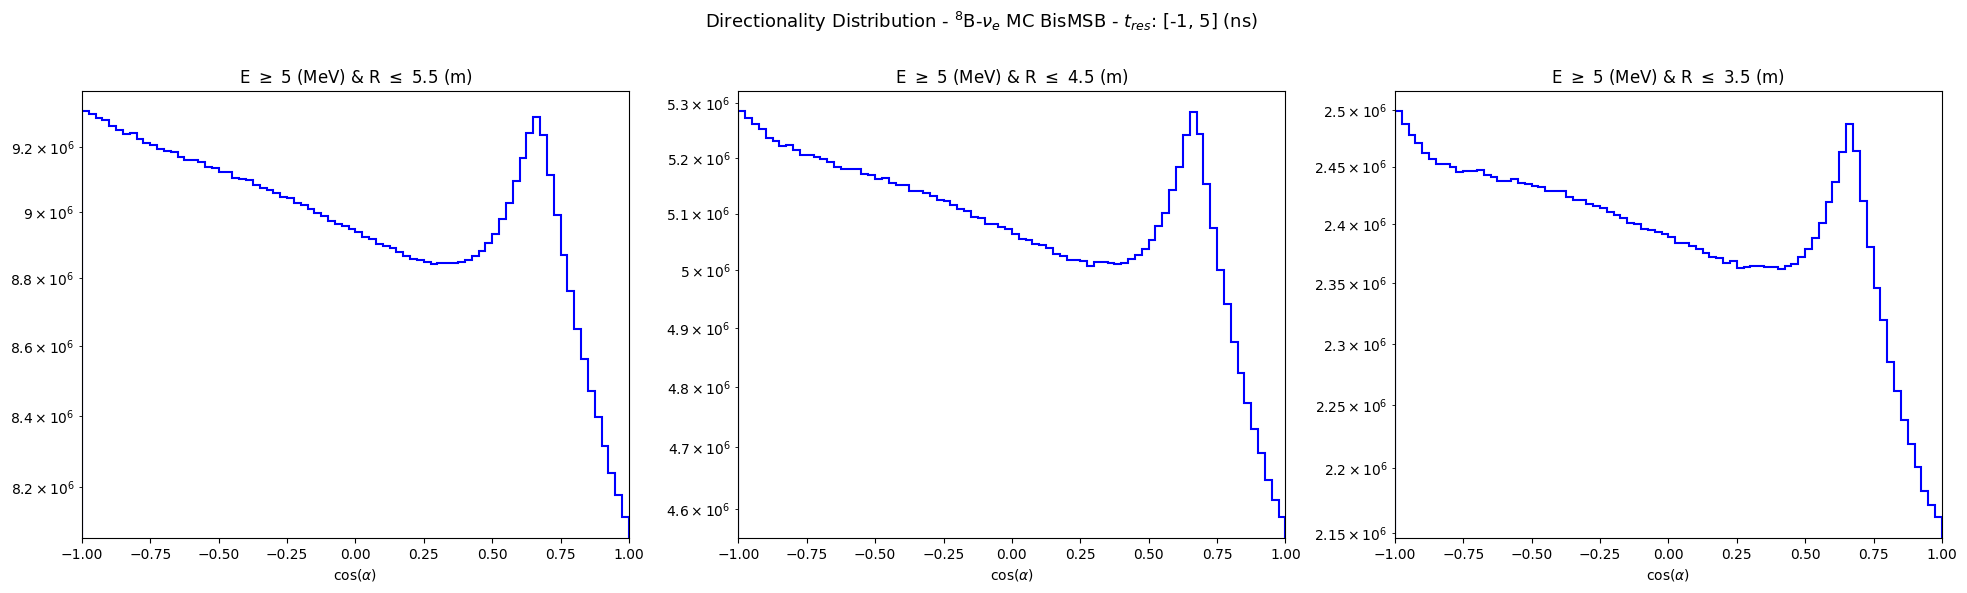

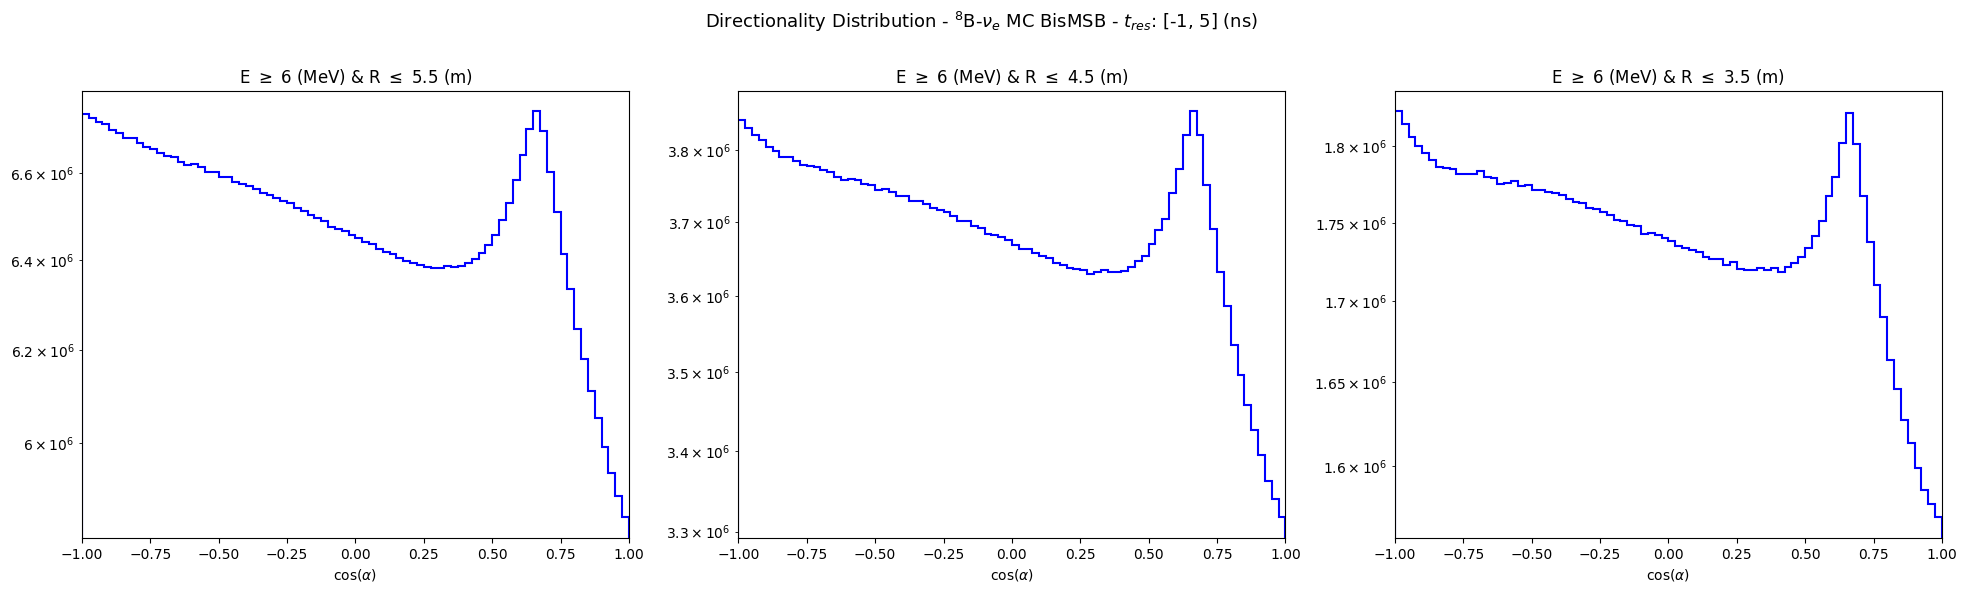

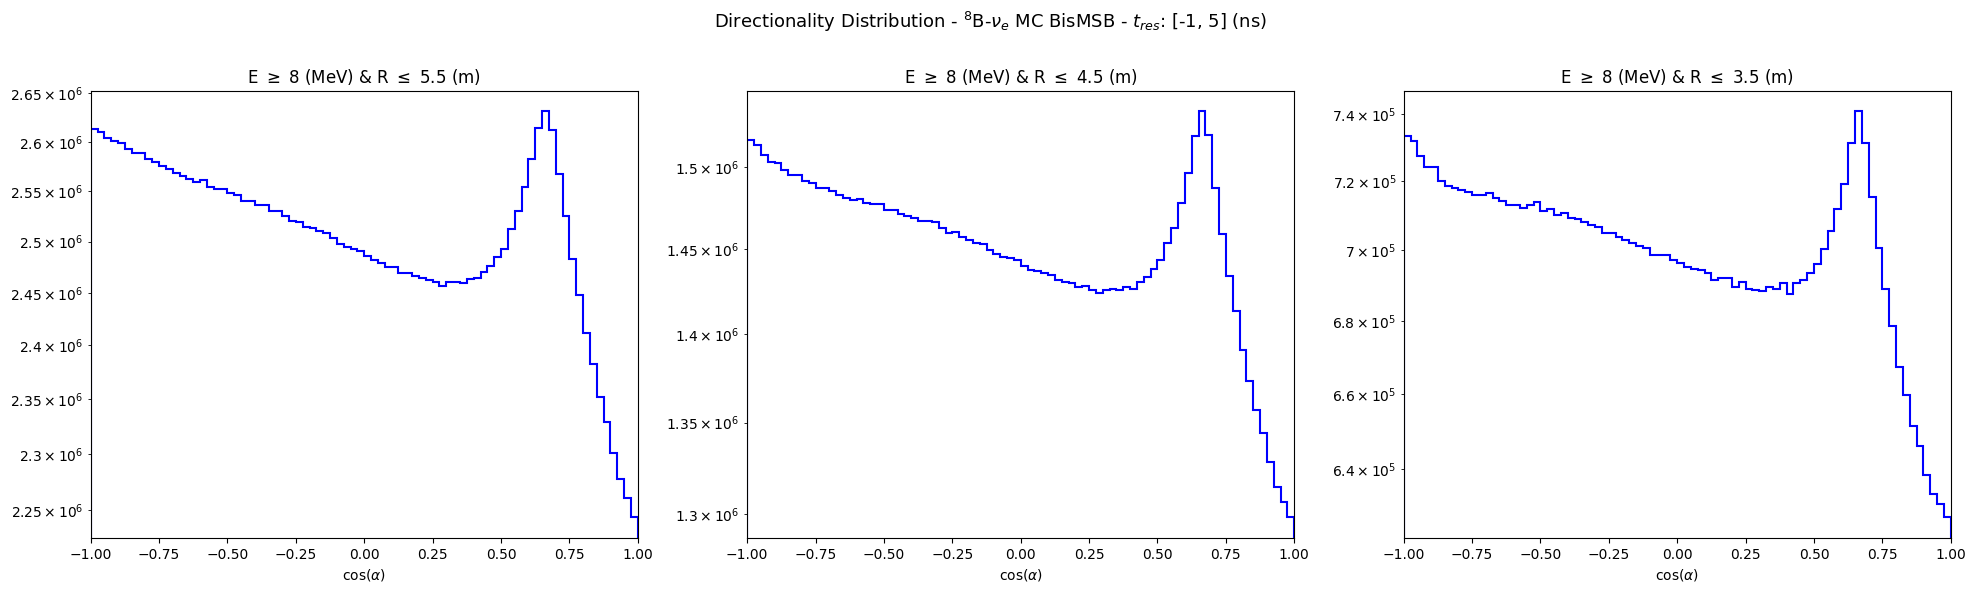

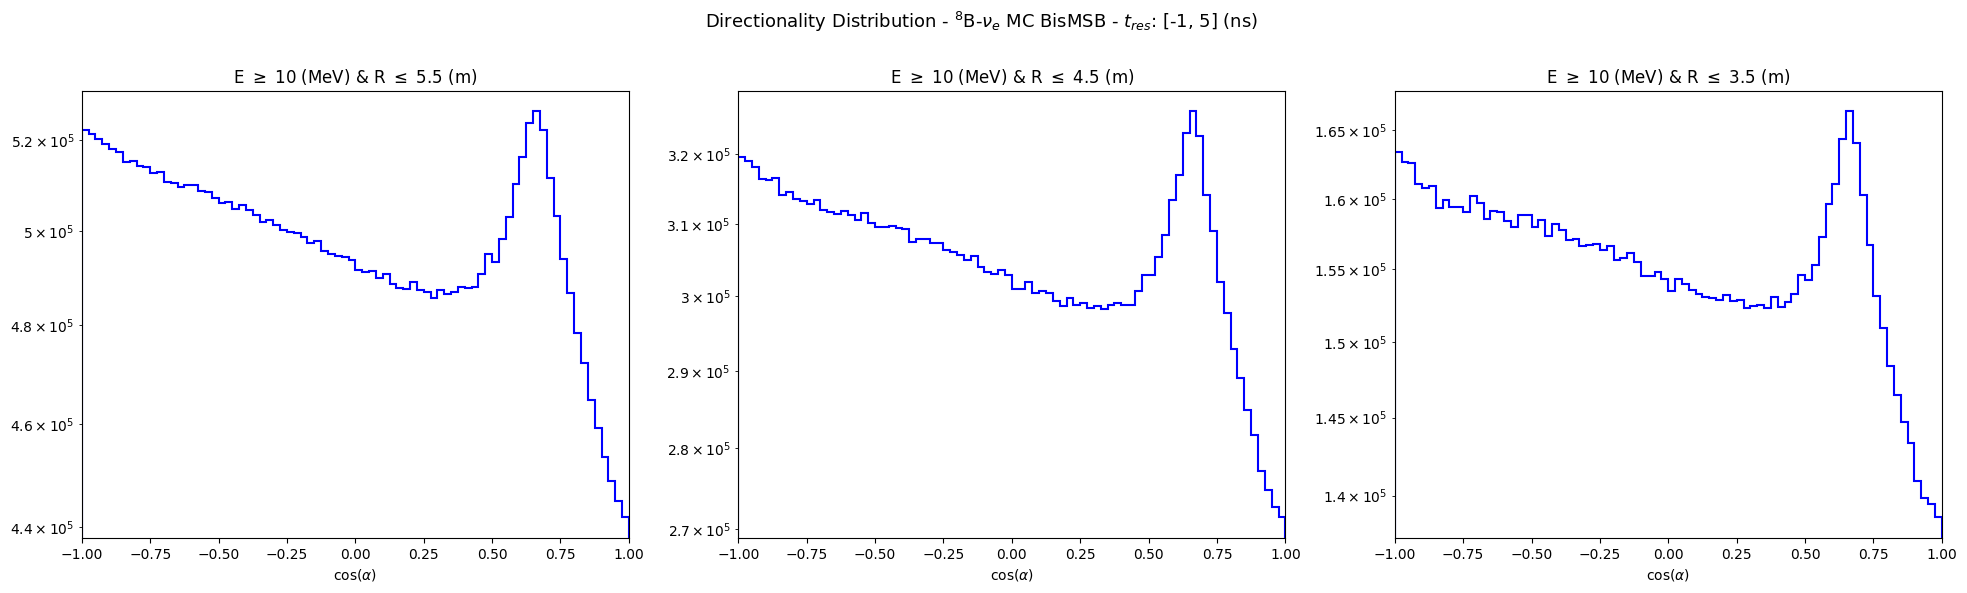

In [13]:
for Ecut_i in E_cut_list:
    
	fig, axes = plt.subplots(1, len(R_cut_list), figsize=(24, 5.8))

	for i_dx, Rcut_i in enumerate(R_cut_list):
		ax = axes[i_dx]

		# Recuperamos los conteos que calculamos en el loop de lectura
		counts = hist_data[Ecut_i][Rcut_i]

		ax.hist(bin_edges[:-1], bins=bin_edges, weights=counts, histtype='step', color='blue', linewidth=1.5)

		ax.set_title(rf'E $\geq$ {Ecut_i} (MeV) & R $\leq$ {Rcut_i*10**-3:.1f} (m)')
		ax.set_yscale('log')
		ax.set_xlabel(r'cos($\alpha$)')
		ax.set_xlim(-1, 1)


	plt.suptitle(rf'Directionality Distribution - $^8$B-$\nu_e$ MC BisMSB - $t_{{res}}$: [{t_res_min_cut:.0f}, {t_res_max_cut:.0f}] (ns)', fontsize=13, y=1.02)
    

In [8]:
print(fr'{t_res_max:.0f}')

50
